In [1]:
!pip install pyECLAT mlxtend

In [12]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
import pandas as pd
from pyECLAT import ECLAT

In [14]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/Groceries_dataset.csv")

In [15]:
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [16]:
transactions = (
    df.groupby(['Member_number','Date'])['itemDescription']
    .apply(list)
    .tolist()
)

transaction_df = pd.DataFrame(transactions)

In [17]:
eclat = ECLAT(transaction_df)

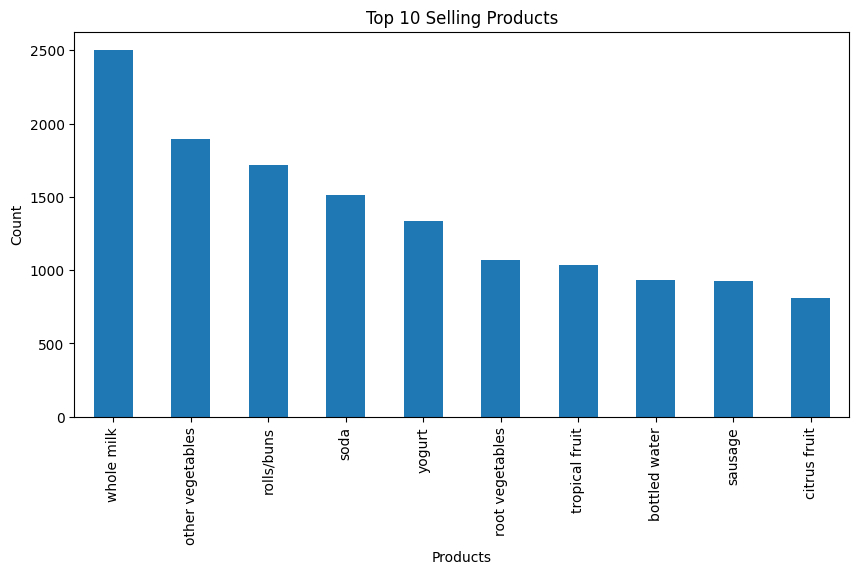

In [18]:
import matplotlib.pyplot as plt

top_products = (
    df['itemDescription']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Count")

plt.show()

In [19]:
indices, support = eclat.fit(
    min_support=0.02,
    min_combination=1,
    max_combination=2
)

print(support)

Combination 1 by 1


38it [00:04,  7.74it/s]


Combination 2 by 2


703it [00:23, 30.53it/s]

{'white bread': 0.023992514870012697, 'berries': 0.021787074784468355, 'coffee': 0.03161130789280225, 'bottled beer': 0.04531176903027468, 'curd': 0.03368308494285905, 'tropical fruit': 0.0677671589921807, 'sausage': 0.06034886052262247, 'margarine': 0.03221279155249616, 'cream cheese ': 0.023658357281293858, 'pastry': 0.0517275947336764, 'frozen vegetables': 0.028002405934638777, 'whipped/sour cream': 0.043707812604424245, 'pip fruit': 0.049054334023925686, 'rolls/buns': 0.11000467820624206, 'pork': 0.037091492347791216, 'chicken': 0.027868742899151238, 'onions': 0.02024994987636169, 'frankfurter': 0.037759807525228894, 'dessert': 0.02359152576355009, 'fruit/vegetable juice': 0.03401724253157789, 'napkins': 0.022121232373187194, 'canned beer': 0.04691572545612511, 'root vegetables': 0.06957160997126245, 'newspapers': 0.038895943326872955, 'soda': 0.09710619528169484, 'butter': 0.03522020985096572, 'beef': 0.03395041101383412, 'brown bread': 0.03762614448974136, 'domestic eggs': 0.0370

In [20]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

In [21]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/Groceries_dataset.csv")

In [22]:
transactions = (
    df.groupby(['Member_number','Date'])['itemDescription']
    .apply(list)
    .tolist()
)

In [23]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print(basket.head())

   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

In [27]:
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.005,
    use_colnames=True
)

print(frequent_itemsets.head())

    support               itemsets
0  0.157923           (whole milk)
1  0.085879               (yogurt)
2  0.060349              (sausage)
3  0.009490  (semi-finished bread)
4  0.051728               (pastry)


In [29]:
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
0,0.157923,(whole milk)
17,0.122101,(other vegetables)
13,0.110005,(rolls/buns)
9,0.097106,(soda)
1,0.085879,(yogurt)
24,0.069572,(root vegetables)
20,0.067767,(tropical fruit)
34,0.060683,(bottled water)
2,0.060349,(sausage)
51,0.053131,(citrus fruit)


In [30]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.1
)

print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

           antecedents         consequents   support  confidence      lift
0             (yogurt)        (whole milk)  0.011161    0.129961  0.822940
1            (sausage)        (whole milk)  0.008955    0.148394  0.939663
2             (pastry)        (whole milk)  0.006483    0.125323  0.793571
3        (canned beer)        (whole milk)  0.006015    0.128205  0.811821
4               (soda)        (whole milk)  0.011629    0.119752  0.758296
5        (frankfurter)        (whole milk)  0.005280    0.139823  0.885388
6        (frankfurter)  (other vegetables)  0.005146    0.136283  1.116150
7         (rolls/buns)        (whole milk)  0.013968    0.126974  0.804028
8   (other vegetables)        (whole milk)  0.014837    0.121511  0.769430
9     (tropical fruit)        (whole milk)  0.008220    0.121302  0.768108
10   (root vegetables)        (whole milk)  0.007552    0.108549  0.687357
11         (pip fruit)        (whole milk)  0.006616    0.134877  0.854071
12     (shopping bags)   

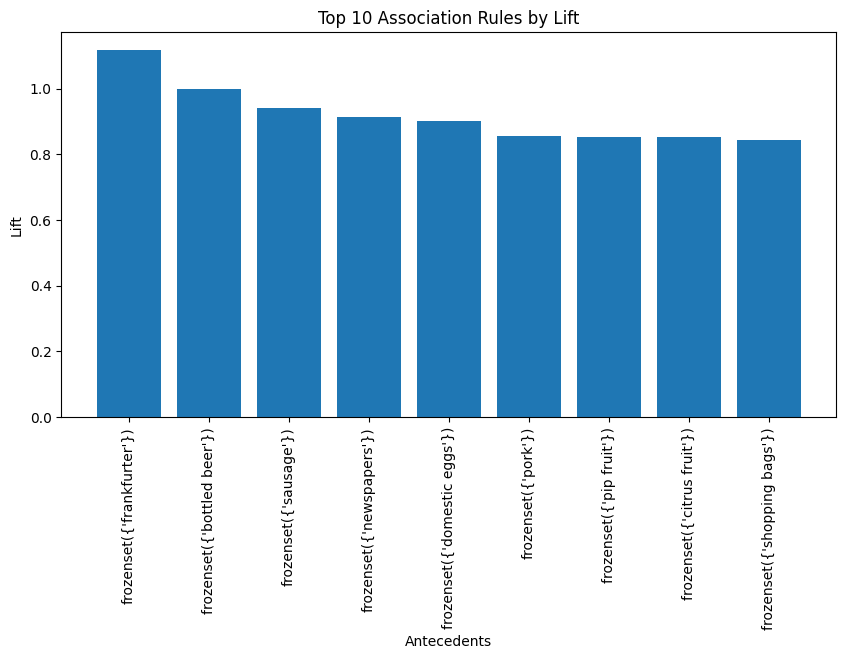

In [31]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_rules['antecedents'].astype(str),
    top_rules['lift']
)

plt.xticks(rotation=90)

plt.title("Top 10 Association Rules by Lift")
plt.xlabel("Antecedents")
plt.ylabel("Lift")

plt.show()

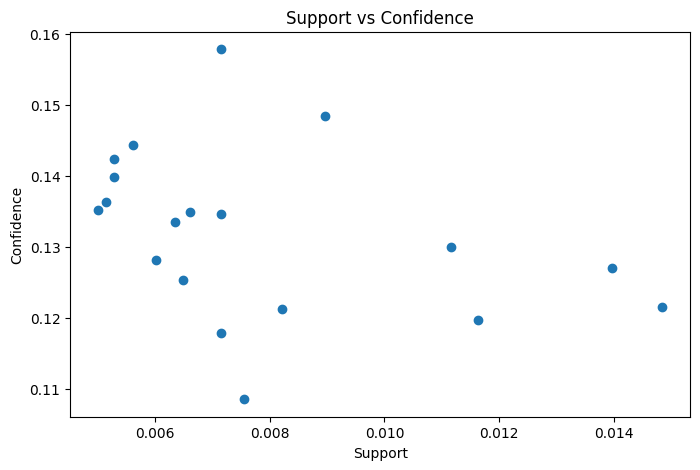

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title("Support vs Confidence")

plt.show()

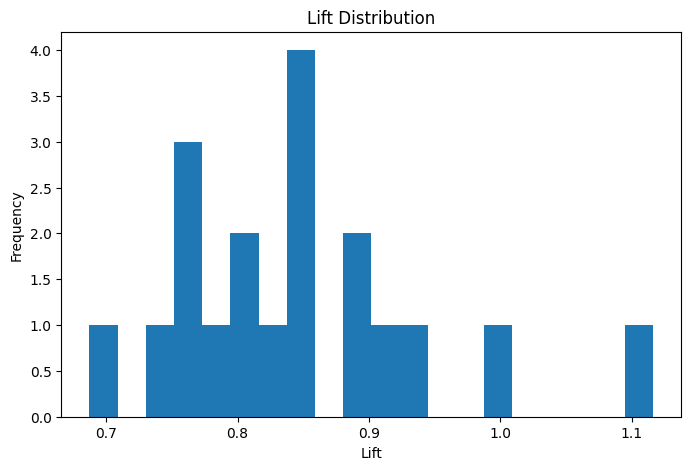

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    rules['lift'],
    bins=20
)

plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")

plt.show()